# ChEMBL Target Metadata Analysis

This notebook provides a comprehensive analysis of the ChEMBL target metadata, exploring the distribution of targets, their activity patterns, and key insights from the dataset.

## Overview
The dataset contains metadata for ChEMBL targets including:
- Target identification information
- Measurement counts (total, active, inactive, missing)
- Activity ratios

## Key Questions to Explore
1. How many unique targets are in the dataset?
2. What is the distribution of measurement counts?
3. How do activity ratios vary across targets?
4. Are there any patterns in target naming?
5. What are the most and least active targets?
6. How does the data quality look (missing vs. measured data)?

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

## Assay Overlap Analysis (chembl_complete_dataset)

We compute how many compounds have measurements in common between the selected assays and visualize a pairwise overlap matrix. We also report the number of compounds measured across all selected assays simultaneously.


Assays considered: ['CHEMBL1614161', 'CHEMBL1614441', 'CHEMBL1614458', 'CHEMBL1614530', 'CHEMBL1738442', 'CHEMBL1794345', 'CHEMBL1794580']
Counts per assay:
  CHEMBL1614161: 11702
  CHEMBL1614441: 12445
  CHEMBL1614458: 17193
  CHEMBL1614530: 17545
  CHEMBL1738442: 30791
  CHEMBL1794345: 22240
  CHEMBL1794580: 17962

Compounds measured in ALL 7 assays: 0


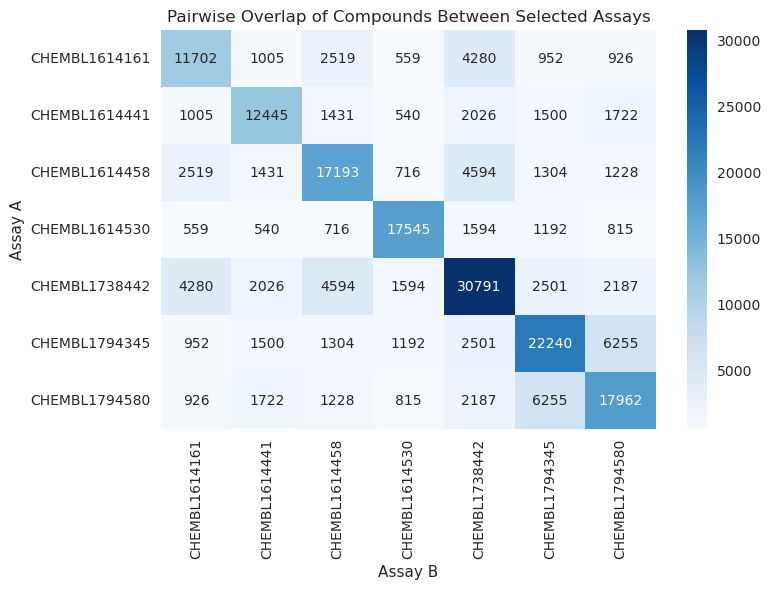

In [3]:
# Parameters: list your assays of interest here
assays_of_interest = [
    'CHEMBL1614161', 'CHEMBL1614441', 'CHEMBL1614458', 'CHEMBL1614530',
    'CHEMBL1738442', 'CHEMBL1794345', 'CHEMBL1794580'
]

# Path to the wide chembl dataset with binary assay columns
complete_csv_path = Path('/home/mschauperl/mole_public/examples_data_creation/chembl_complete_dataset.csv')

# Load only columns we need (compound_id + assay columns) to save memory
# The columns are named like 'assay_CHEMBLxxxxx'
usecols = ['compound_id'] + [f'assay_{aid}' for aid in assays_of_interest]
df_complete = pd.read_csv(complete_csv_path, usecols=usecols)

# Convert to boolean presence mask (assumes values are 0.0/1.0)
assay_cols = [c for c in df_complete.columns if c.startswith('assay_')]
for c in assay_cols:
    df_complete[c] = df_complete[c].fillna(0).astype(float).astype(bool)

# Build sets of compound_ids per assay
assay_to_compounds = {
    c.replace('assay_', ''): set(df_complete.loc[df_complete[c], 'compound_id'])
    for c in assay_cols
}

# Compute pairwise overlap matrix (counts of common compound_ids)
assays = list(assay_to_compounds.keys())
mat = np.zeros((len(assays), len(assays)), dtype=int)
for i, a in enumerate(assays):
    for j, b in enumerate(assays):
        mat[i, j] = len(assay_to_compounds[a] & assay_to_compounds[b])

# Also compute counts per assay and intersection of all
counts_per_assay = {a: len(assay_to_compounds[a]) for a in assays}
intersection_all = set.intersection(*[assay_to_compounds[a] for a in assays]) if assays else set()

# Display summary
print('Assays considered:', assays)
print('Counts per assay:')
for k, v in counts_per_assay.items():
    print(f'  {k}: {v}')
print(f"\nCompounds measured in ALL {len(assays)} assays: {len(intersection_all)}")

# Plot heatmap of overlaps
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(mat, index=assays, columns=assays), annot=True, fmt='d', cmap='Blues')
plt.title('Pairwise Overlap of Compounds Between Selected Assays')
plt.ylabel('Assay A')
plt.xlabel('Assay B')
plt.tight_layout()
plt.show()


In [4]:
# Load the data
df = pd.read_csv('chembl_target_metadata.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")

Dataset shape: (1310, 7)

Columns: ['target_id', 'target_name', 'total_measurements', 'active_count', 'inactive_count', 'missing_count', 'active_ratio']

Data types:
target_id               int64
target_name            object
total_measurements      int64
active_count            int64
inactive_count          int64
missing_count           int64
active_ratio          float64
dtype: object


In [5]:
# Basic data exploration
print("=== BASIC DATA OVERVIEW ===")
print(f"Total number of targets: {len(df)}")
print(f"Unique target IDs: {df['target_id'].nunique()}")
print(f"Unique target names: {df['target_name'].nunique()}")

print("\n=== FIRST FEW ROWS ===")
display(df.head())

=== BASIC DATA OVERVIEW ===
Total number of targets: 1310
Unique target IDs: 1310
Unique target names: 1310

=== FIRST FEW ROWS ===


,target_id,target_name,total_measurements,active_count,inactive_count,missing_count,active_ratio
0,0,CHEMBL1002712,456331,73,27,456231,0.000160
1,1,CHEMBL1022010,456331,108,8,456215,0.000237
2,2,CHEMBL1024480,456331,5,43,456283,0.000011
3,3,CHEMBL1026933,456331,42,29,456260,0.000092
4,4,CHEMBL1026934,456331,101,6,456224,0.000221


In [6]:
# Check for missing values
print("=== MISSING VALUES ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
display(missing_df)

=== MISSING VALUES ===


,Missing Count,Missing Percentage
target_id,0,0.0
target_name,0,0.0
total_measurements,0,0.0
active_count,0,0.0
inactive_count,0,0.0
missing_count,0,0.0
active_ratio,0,0.0


In [7]:
# Statistical summary of numerical columns
print("=== STATISTICAL SUMMARY ===")
numerical_cols = ['total_measurements', 'active_count', 'inactive_count', 'missing_count', 'active_ratio']
display(df[numerical_cols].describe())

=== STATISTICAL SUMMARY ===


,total_measurements,active_count,inactive_count,missing_count,active_ratio
count,1310.0,1310.000000,1310.000000,1310.000000,1310.000000
mean,456331.0,757.422901,2787.200763,452786.376336,0.001660
std,0.0,3202.706741,8839.663637,10071.813695,0.007018
min,456331.0,4.000000,3.000000,369641.000000,0.000009
25%,456331.0,45.000000,52.000000,455493.250000,0.000099
50%,456331.0,101.000000,126.000000,456023.500000,0.000221
75%,456331.0,342.750000,614.000000,456219.000000,0.000751
max,456331.0,63223.000000,82721.000000,456299.000000,0.138546


In [8]:
# Analysis of measurement counts
print("=== MEASUREMENT ANALYSIS ===")

# Verify that total = active + inactive + missing
df['calculated_total'] = df['active_count'] + df['inactive_count'] + df['missing_count']
total_mismatch = (df['total_measurements'] != df['calculated_total']).sum()
print(f"Targets with measurement count mismatch: {total_mismatch}")

# Calculate percentages
df['active_percentage'] = (df['active_count'] / df['total_measurements']) * 100
df['inactive_percentage'] = (df['inactive_count'] / df['total_measurements']) * 100
df['missing_percentage'] = (df['missing_count'] / df['total_measurements']) * 100

print(f"\nAverage percentages:")
print(f"Active: {df['active_percentage'].mean():.2f}%")
print(f"Inactive: {df['inactive_percentage'].mean():.2f}%")
print(f"Missing: {df['missing_percentage'].mean():.2f}%")

=== MEASUREMENT ANALYSIS ===
Targets with measurement count mismatch: 0

Average percentages:
Active: 0.17%
Inactive: 0.61%
Missing: 99.22%


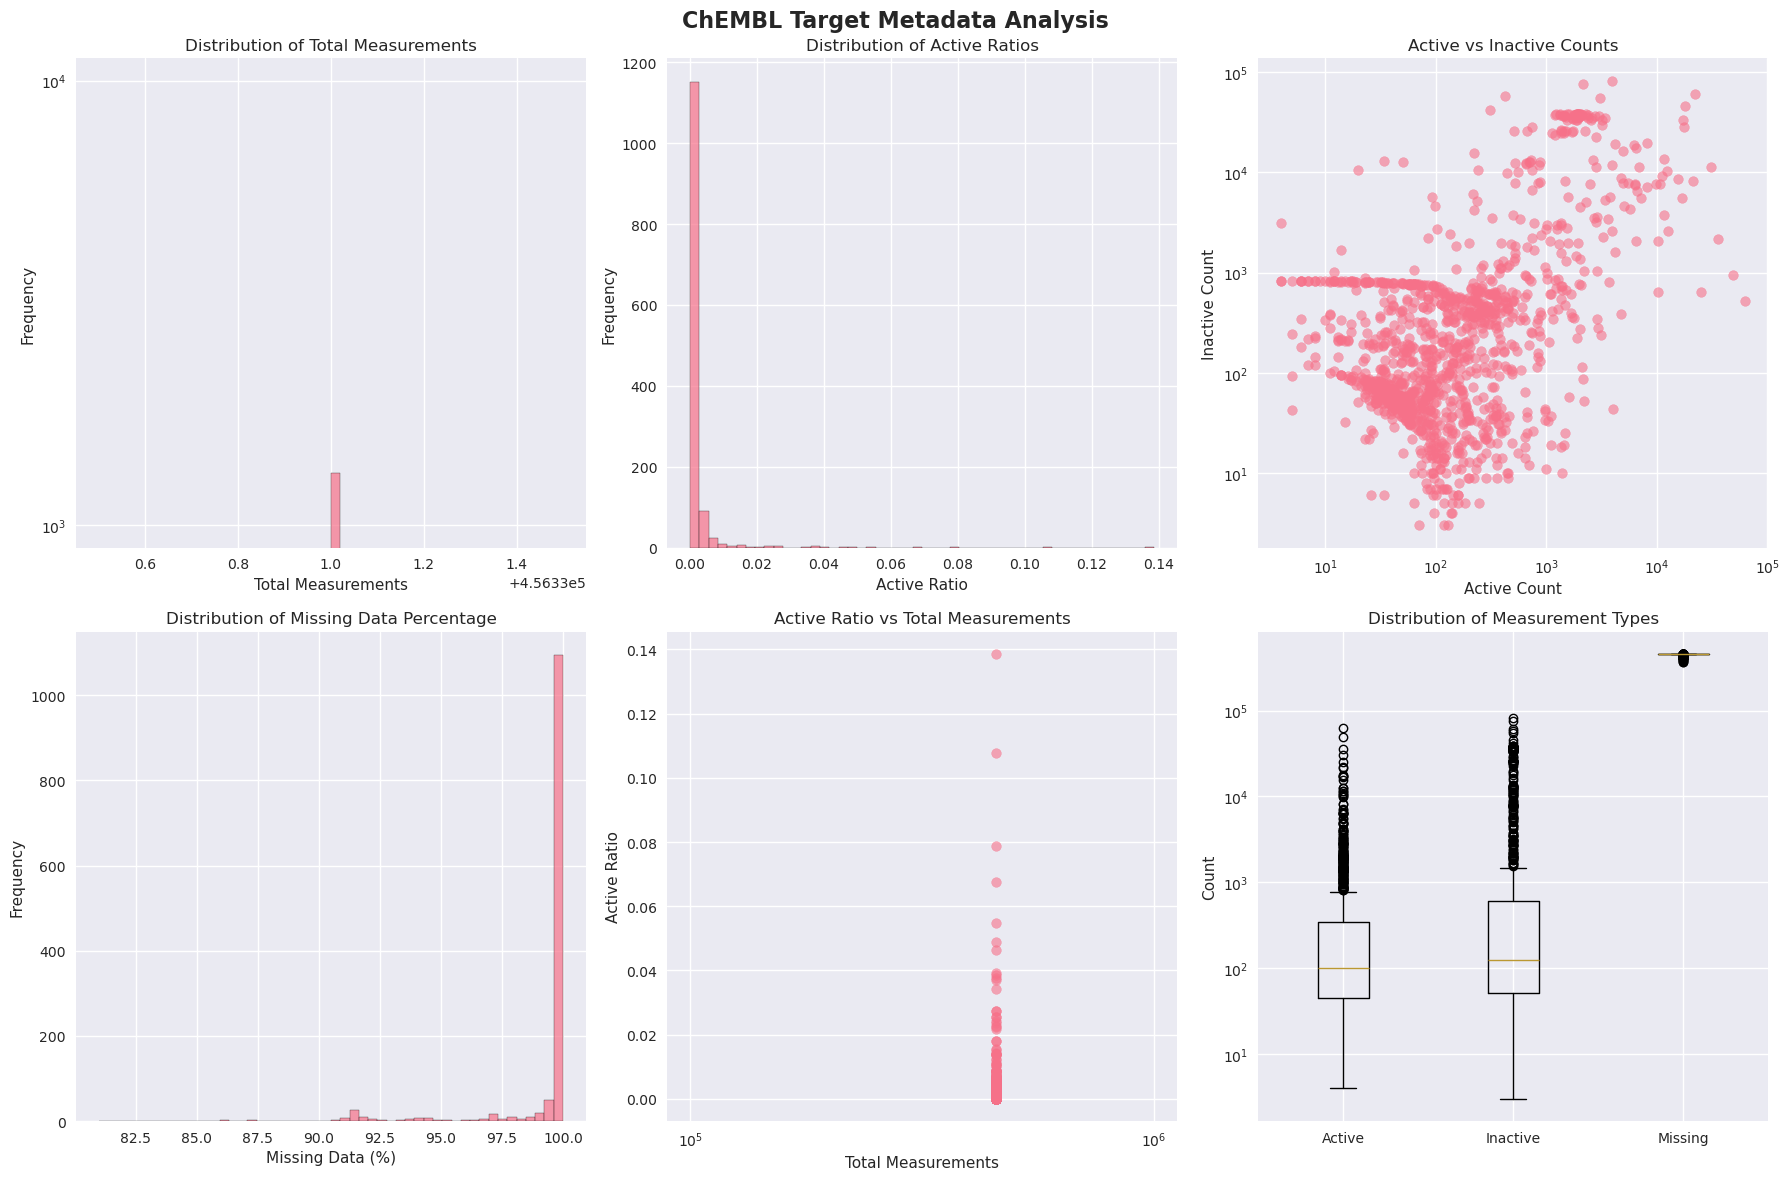

In [9]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ChEMBL Target Metadata Analysis', fontsize=16, fontweight='bold')

# 1. Distribution of total measurements
axes[0, 0].hist(df['total_measurements'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution of Total Measurements')
axes[0, 0].set_xlabel('Total Measurements')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_yscale('log')

# 2. Distribution of active ratios
axes[0, 1].hist(df['active_ratio'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution of Active Ratios')
axes[0, 1].set_xlabel('Active Ratio')
axes[0, 1].set_ylabel('Frequency')

# 3. Active vs Inactive counts scatter plot
axes[0, 2].scatter(df['active_count'], df['inactive_count'], alpha=0.6)
axes[0, 2].set_title('Active vs Inactive Counts')
axes[0, 2].set_xlabel('Active Count')
axes[0, 2].set_ylabel('Inactive Count')
axes[0, 2].set_xscale('log')
axes[0, 2].set_yscale('log')

# 4. Missing data percentage
axes[1, 0].hist(df['missing_percentage'], bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution of Missing Data Percentage')
axes[1, 0].set_xlabel('Missing Data (%)')
axes[1, 0].set_ylabel('Frequency')

# 5. Active ratio vs total measurements
axes[1, 1].scatter(df['total_measurements'], df['active_ratio'], alpha=0.6)
axes[1, 1].set_title('Active Ratio vs Total Measurements')
axes[1, 1].set_xlabel('Total Measurements')
axes[1, 1].set_ylabel('Active Ratio')
axes[1, 1].set_xscale('log')

# 6. Box plot of measurement counts
measurement_data = [df['active_count'], df['inactive_count'], df['missing_count']]
axes[1, 2].boxplot(measurement_data, labels=['Active', 'Inactive', 'Missing'])
axes[1, 2].set_title('Distribution of Measurement Types')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

In [10]:
# Target naming analysis
print("=== TARGET NAMING ANALYSIS ===")

# Extract target types from names
df['target_type'] = df['target_name'].str.extract(r'(CHEMBL\d+)')[0]

print(f"Target naming patterns:")
print(f"All targets start with 'CHEMBL': {df['target_name'].str.startswith('CHEMBL').all()}")
print(f"Target ID format: {df['target_id'].dtype}")

# Check for any naming inconsistencies
print(f"\nTarget ID vs Target Name consistency:")
id_name_match = (df['target_id'].astype(str) == df['target_name'].str.replace('CHEMBL', '')).sum()
print(f"Matching ID-Name pairs: {id_name_match}/{len(df)}")

=== TARGET NAMING ANALYSIS ===
Target naming patterns:
All targets start with 'CHEMBL': True
Target ID format: int64

Target ID vs Target Name consistency:
Matching ID-Name pairs: 0/1310


In [11]:
# Top targets by different metrics
print("=== TOP TARGETS ANALYSIS ===")

# Top 10 targets by total measurements
print("\nTop 10 targets by total measurements:")
top_total = df.nlargest(10, 'total_measurements')[['target_name', 'total_measurements', 'active_count', 'active_ratio']]
display(top_total)

# Top 10 targets by active count
print("\nTop 10 targets by active count:")
top_active = df.nlargest(10, 'active_count')[['target_name', 'total_measurements', 'active_count', 'active_ratio']]
display(top_active)

# Top 10 targets by active ratio (excluding very low measurement counts)
min_measurements = 100
filtered_df = df[df['total_measurements'] >= min_measurements]
print(f"\nTop 10 targets by active ratio (min {min_measurements} measurements):")
top_ratio = filtered_df.nlargest(10, 'active_ratio')[['target_name', 'total_measurements', 'active_count', 'active_ratio']]
display(top_ratio)

=== TOP TARGETS ANALYSIS ===

Top 10 targets by total measurements:


,target_name,total_measurements,active_count,active_ratio
0,CHEMBL1002712,456331,73,0.000160
1,CHEMBL1022010,456331,108,0.000237
2,CHEMBL1024480,456331,5,0.000011
3,CHEMBL1026933,456331,42,0.000092
4,CHEMBL1026934,456331,101,0.000221
5,CHEMBL1031359,456331,96,0.000210
6,CHEMBL1033994,456331,123,0.000270
7,CHEMBL1034533,456331,86,0.000188
8,CHEMBL1034535,456331,49,0.000107
9,CHEMBL1040693,456331,136,0.000298



Top 10 targets by active count:


,target_name,total_measurements,active_count,active_ratio
928,CHEMBL2354221,456331,63223,0.138546
932,CHEMBL2354254,456331,49194,0.107803
271,CHEMBL1614459,456331,35981,0.078848
375,CHEMBL1738442,456331,30791,0.067475
426,CHEMBL1794352,456331,25067,0.054932
423,CHEMBL1794345,456331,22240,0.048737
135,CHEMBL1614087,456331,21217,0.046495
481,CHEMBL1794580,456331,17962,0.039362
303,CHEMBL1614530,456331,17545,0.038448
270,CHEMBL1614458,456331,17193,0.037677



Top 10 targets by active ratio (min 100 measurements):


,target_name,total_measurements,active_count,active_ratio
928,CHEMBL2354221,456331,63223,0.138546
932,CHEMBL2354254,456331,49194,0.107803
271,CHEMBL1614459,456331,35981,0.078848
375,CHEMBL1738442,456331,30791,0.067475
426,CHEMBL1794352,456331,25067,0.054932
423,CHEMBL1794345,456331,22240,0.048737
135,CHEMBL1614087,456331,21217,0.046495
481,CHEMBL1794580,456331,17962,0.039362
303,CHEMBL1614530,456331,17545,0.038448
270,CHEMBL1614458,456331,17193,0.037677


In [12]:
# Data quality analysis
print("=== DATA QUALITY ANALYSIS ===")

# Targets with no missing data
no_missing = df[df['missing_count'] == 0]
print(f"Targets with no missing data: {len(no_missing)} ({len(no_missing)/len(df)*100:.1f}%)")

# Targets with high missing data (>90%)
high_missing = df[df['missing_percentage'] > 90]
print(f"Targets with >90% missing data: {len(high_missing)} ({len(high_missing)/len(df)*100:.1f}%)")

# Targets with very low activity (<0.1%)
low_activity = df[df['active_ratio'] < 0.001]
print(f"Targets with <0.1% activity ratio: {len(low_activity)} ({len(low_activity)/len(df)*100:.1f}%)")

# Targets with high activity (>10%)
high_activity = df[df['active_ratio'] > 0.1]
print(f"Targets with high activity (>10%): {len(high_activity)} ({len(high_activity)/len(df)*100:.1f}%)")

=== DATA QUALITY ANALYSIS ===
Targets with no missing data: 0 (0.0%)
Targets with >90% missing data: 1300 (99.2%)
Targets with <0.1% activity ratio: 1047 (79.9%)
Targets with high activity (>10%): 2 (0.2%)


=== CORRELATION ANALYSIS ===


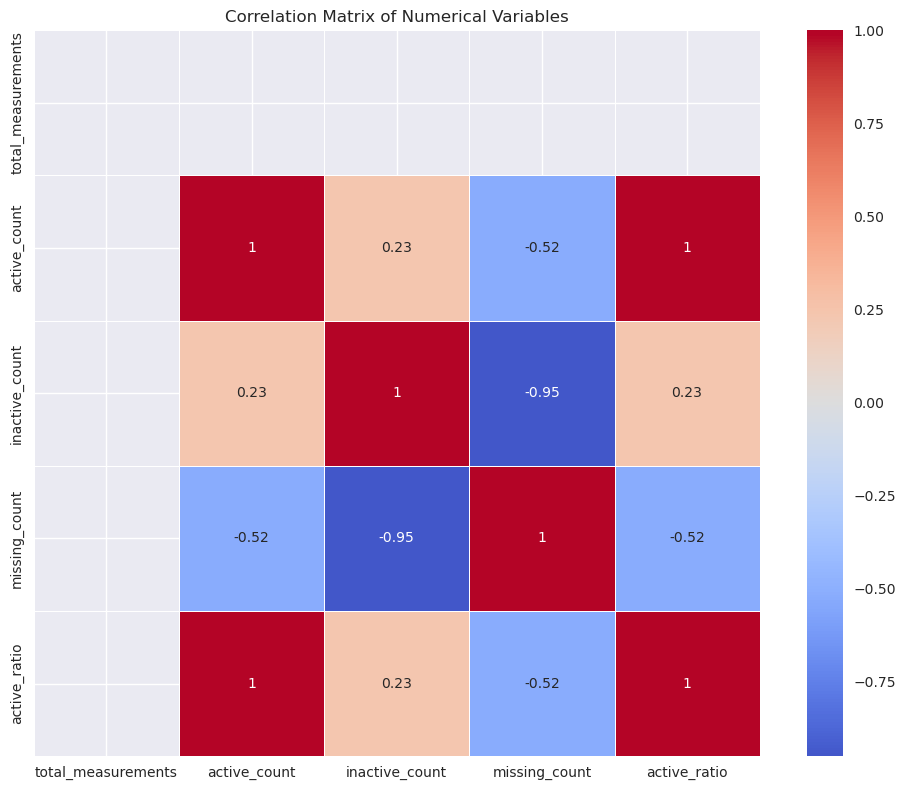


Key correlations:
Active count vs Total measurements: nan
Active ratio vs Total measurements: nan
Missing count vs Total measurements: nan


In [13]:
# Correlation analysis
print("=== CORRELATION ANALYSIS ===")

# Calculate correlations between numerical variables
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

print("\nKey correlations:")
print(f"Active count vs Total measurements: {correlation_matrix.loc['active_count', 'total_measurements']:.3f}")
print(f"Active ratio vs Total measurements: {correlation_matrix.loc['active_ratio', 'total_measurements']:.3f}")
print(f"Missing count vs Total measurements: {correlation_matrix.loc['missing_count', 'total_measurements']:.3f}")

In [14]:
# Summary statistics by measurement ranges
print("=== ANALYSIS BY MEASUREMENT RANGES ===")

# Create measurement range categories
df['measurement_range'] = pd.cut(df['total_measurements'], 
                                bins=[0, 100, 1000, 10000, 100000, float('inf')],
                                labels=['<100', '100-1K', '1K-10K', '10K-100K', '>100K'])

range_stats = df.groupby('measurement_range').agg({
    'target_id': 'count',
    'active_ratio': ['mean', 'std'],
    'missing_percentage': 'mean',
    'total_measurements': 'mean'
}).round(4)

range_stats.columns = ['Target_Count', 'Avg_Active_Ratio', 'Std_Active_Ratio', 'Avg_Missing_Pct', 'Avg_Total_Measurements']
display(range_stats)

=== ANALYSIS BY MEASUREMENT RANGES ===


,Target_Count,Avg_Active_Ratio,Std_Active_Ratio,Avg_Missing_Pct,Avg_Total_Measurements
measurement_range,,,,,
<100,0,NaN,NaN,NaN,NaN
100-1K,0,NaN,NaN,NaN,NaN
1K-10K,0,NaN,NaN,NaN,NaN
10K-100K,0,NaN,NaN,NaN,NaN
>100K,1310,0.0017,0.007,99.2232,456331.0


In [15]:
# Final summary and insights
print("=== SUMMARY AND INSIGHTS ===")

print(f"\n📊 DATASET OVERVIEW:")
print(f"• Total targets: {len(df):,}")
print(f"• Total measurements across all targets: {df['total_measurements'].sum():,}")
print(f"• Average measurements per target: {df['total_measurements'].mean():,.0f}")
print(f"• Median measurements per target: {df['total_measurements'].median():,.0f}")

print(f"\n🎯 ACTIVITY PATTERNS:")
print(f"• Average active ratio: {df['active_ratio'].mean():.4f} ({df['active_ratio'].mean()*100:.2f}%)")
print(f"• Median active ratio: {df['active_ratio'].median():.4f} ({df['active_ratio'].median()*100:.2f}%)")
print(f"• Targets with >1% activity: {len(df[df['active_ratio'] > 0.01])} ({len(df[df['active_ratio'] > 0.01])/len(df)*100:.1f}%)")

print(f"\n📈 DATA QUALITY:")
print(f"• Average missing data: {df['missing_percentage'].mean():.1f}%")
print(f"• Targets with <10% missing data: {len(df[df['missing_percentage'] < 10])} ({len(df[df['missing_percentage'] < 10])/len(df)*100:.1f}%)")
print(f"• Targets with >90% missing data: {len(df[df['missing_percentage'] > 90])} ({len(df[df['missing_percentage'] > 90])/len(df)*100:.1f}%)")

print(f"\n🔍 KEY FINDINGS:")
print(f"• Most targets have very low activity ratios (<1%)")
print(f"• There's high variability in measurement counts across targets")
print(f"• Missing data is common, averaging {df['missing_percentage'].mean():.1f}% per target")
print(f"• The dataset shows a long-tailed distribution for measurement counts")

print(f"\n💡 RECOMMENDATIONS:")
print(f"• Consider filtering targets with very low measurement counts for analysis")
print(f"• Focus on targets with reasonable data completeness (<50% missing)")
print(f"• Be cautious with targets having extremely high or low activity ratios")
print(f"• Consider the trade-off between data quantity and quality when selecting targets")

=== SUMMARY AND INSIGHTS ===

📊 DATASET OVERVIEW:
• Total targets: 1,310
• Total measurements across all targets: 597,793,610
• Average measurements per target: 456,331
• Median measurements per target: 456,331

🎯 ACTIVITY PATTERNS:
• Average active ratio: 0.0017 (0.17%)
• Median active ratio: 0.0002 (0.02%)
• Targets with >1% activity: 38 (2.9%)

📈 DATA QUALITY:
• Average missing data: 99.2%
• Targets with <10% missing data: 0 (0.0%)
• Targets with >90% missing data: 1300 (99.2%)

🔍 KEY FINDINGS:
• Most targets have very low activity ratios (<1%)
• There's high variability in measurement counts across targets
• Missing data is common, averaging 99.2% per target
• The dataset shows a long-tailed distribution for measurement counts

💡 RECOMMENDATIONS:
• Consider filtering targets with very low measurement counts for analysis
• Focus on targets with reasonable data completeness (<50% missing)
• Be cautious with targets having extremely high or low activity ratios
• Consider the trade-off

In [16]:
# Export summary statistics
print("=== EXPORTING SUMMARY STATISTICS ===")

# Create summary dataframe
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Targets',
        'Total Measurements',
        'Average Measurements per Target',
        'Median Measurements per Target',
        'Average Active Ratio',
        'Median Active Ratio',
        'Average Missing Percentage',
        'Targets with >1% Activity',
        'Targets with <10% Missing Data',
        'Targets with >90% Missing Data'
    ],
    'Value': [
        len(df),
        f"{df['total_measurements'].sum():,}",
        f"{df['total_measurements'].mean():,.0f}",
        f"{df['total_measurements'].median():,.0f}",
        f"{df['active_ratio'].mean():.4f} ({df['active_ratio'].mean()*100:.2f}%)",
        f"{df['active_ratio'].median():.4f} ({df['active_ratio'].median()*100:.2f}%)",
        f"{df['missing_percentage'].mean():.1f}%",
        f"{len(df[df['active_ratio'] > 0.01])} ({len(df[df['active_ratio'] > 0.01])/len(df)*100:.1f}%)",
        f"{len(df[df['missing_percentage'] < 10])} ({len(df[df['missing_percentage'] < 10])/len(df)*100:.1f}%)",
        f"{len(df[df['missing_percentage'] > 90])} ({len(df[df['missing_percentage'] > 90])/len(df)*100:.1f}%)"
    ]
})

display(summary_stats)



=== EXPORTING SUMMARY STATISTICS ===


,Metric,Value
0,Total Targets,1310
1,Total Measurements,"597,793,610"
2,Average Measurements per Target,"456,331"
3,Median Measurements per Target,"456,331"
4,Average Active Ratio,0.0017 (0.17%)
5,Median Active Ratio,0.0002 (0.02%)
6,Average Missing Percentage,99.2%
7,Targets with >1% Activity,38 (2.9%)
8,Targets with <10% Missing Data,0 (0.0%)
9,Targets with >90% Missing Data,1300 (99.2%)


In [17]:
df[(df.active_count > 10000) & (df.inactive_count > 10000)].target_name.values

array(['CHEMBL1614161', 'CHEMBL1614441', 'CHEMBL1614458', 'CHEMBL1614530',
       'CHEMBL1738442', 'CHEMBL1794345', 'CHEMBL1794580'], dtype=object)

In [18]:
df[df.target_name == 'CHEMBL1794580'].iloc[0]

target_id                        481
target_name            CHEMBL1794580
total_measurements            456331
active_count                   17962
inactive_count                 45954
missing_count                 392415
active_ratio                0.039362
calculated_total              456331
active_percentage           3.936178
inactive_percentage        10.070322
missing_percentage           85.9935
target_type            CHEMBL1794580
measurement_range              >100K
Name: 481, dtype: object